In [1]:
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Get Data

In [2]:
df = pd.read_csv("C:/Users/Abhineet/Documents/LEPSUCD/log2.csv")
ppg = df[['IR', 'RED', 'SpO2', 'HeartRate', 'RatioAverage']].to_numpy()

rt = ppg[:, 4] # RatioAverage
hr = ppg[:, 3] # HeartRate
sp = ppg[:, 2] # SpO2
rd = ppg[:, 1] # RED
ir = ppg[:, 0] # IR

In [3]:
%matplotlib widget

## Plot Data

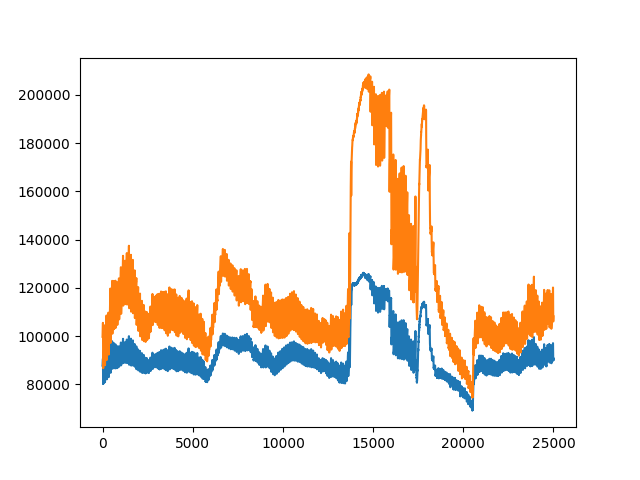

In [4]:
plt.figure()
plt.plot(rd)
plt.plot(ir)

In [5]:
heart_rate = []
spo2 = []
ratios = []
SF_spo2 = 25
BUFFER_SIZE = SF_spo2 * 4
first_calc_idx = 0

old_rt = rt[0]
for i in range(1, len(rt)):
    if (rt[i] != old_rt):
        first_calc_idx = i
        break
    old_rt = rt[i]

first_calc_possible = (first_calc_idx % 2100) == 0
if not first_calc_possible: first_calc_idx = first_calc_idx % 2100
else:
    if first_calc_idx > 2100: first_calc_idx = 2100

## Peak Detector

In [6]:
def find_peak_above(peak_locs, an_x, size, min_height, max_num_peaks) -> Tuple[np.ndarray, int]:
    i = 1
    width = 0
    num_peaks = 0

    while (i < size - 1):
        if (an_x[i] > min_height and an_x[i] > an_x[i - 1]): # find left edge of potential peaks
            width = 1

            while (i + width < size and an_x[i] == an_x[i + width]): # find flat peaks
                width += 1
            
            if (an_x[i] > an_x[i + width] and num_peaks < max_num_peaks): # find right edge of peaks
                peak_locs[num_peaks] = i
                num_peaks += 1
                i += width + 1
            else:
                i += width
        else:
            i += 1
    
    return peak_locs, num_peaks

def sort_ascending(buff, size) -> np.ndarray:
    temp = 0

    for i in range(size):
        temp = buff[i]

        j = i
        while (j > 0 and temp < buff[j - 1]):
            buff[j] = buff[j - 1]
            j -= 1
        
        buff[j] = temp
    
    return buff

def sort_peaks_descending(an_x, peak_locs, size) -> np.ndarray:
    peak_locs = np.int_(peak_locs)
    temp = 0

    for i in range(size):
        temp = peak_locs[i]

        j = i
        while (j > 0 and an_x[temp] > an_x[peak_locs[j - 1]]):
            peak_locs[j] = peak_locs[j - 1]
            j -= 1
        
        peak_locs[j] = temp
    
    return peak_locs

def remove_close_peaks(peak_locs, an_x, num_peaks, min_distance) -> Tuple[np.ndarray, int]:
    old_num_peaks = 0
    dist = 0
    peak_locs = sort_peaks_descending(an_x, peak_locs, num_peaks) # sort peaks from large to small

    i = -1
    while (i < num_peaks):
        old_num_peaks = num_peaks
        num_peaks = i + 1

        for j in range(i + 1, old_num_peaks):
            dist = peak_locs[j] - (-1 if i == -1 else peak_locs[i])
            if (abs(dist) > min_distance):
                peak_locs[num_peaks] = peak_locs[j]
                num_peaks += 1
        
        i += 1
    
    peak_locs = sort_ascending(peak_locs, num_peaks) # re-sort in ascending order
    return peak_locs, num_peaks

def find_peaks(peak_locs, an_x, size, min_height, min_distance, max_num_peaks) -> Tuple[np.ndarray, int]:
    peak_locs, num_peaks = find_peak_above(peak_locs, an_x, size, min_height, max_num_peaks)
    peak_locs, num_peaks = remove_close_peaks(peak_locs, an_x, num_peaks, min_distance)

    return peak_locs, num_peaks

## SpO2 Calculation Algorithm

In [7]:
uch_spo2_table = [95, 95, 95, 96, 96, 96, 97, 97, 97, 97, 97, 98, 98, 98, 98, 98, 99, 99, 99, 99,
                    99, 99, 99, 99, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
                    100, 100, 100, 100, 99, 99, 99, 99, 99, 99, 99, 99, 98, 98, 98, 98, 98, 98, 97, 97,
                    97, 97, 96, 96, 96, 96, 95, 95, 95, 94, 94, 94, 93, 93, 93, 92, 92, 92, 91, 91,
                    90, 90, 89, 89, 89, 88, 88, 87, 87, 86, 86, 85, 85, 84, 84, 83, 82, 82, 81, 81,
                    80, 80, 79, 78, 78, 77, 76, 76, 75, 74, 74, 73, 72, 72, 71, 70, 69, 69, 68, 67,
                    66, 66, 65, 64, 63, 62, 62, 61, 60, 59, 58, 57, 56, 56, 55, 54, 53, 52, 51, 50,
                    49, 48, 47, 46, 45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 31, 30, 29,
                    28, 27, 26, 25, 23, 22, 21, 20, 19, 17, 16, 15, 14, 12, 11, 10, 9, 7, 6, 5,
                    3, 2, 1]

def find_spo2(ir_buff: np.ndarray, rd_buff: np.ndarray, plotting_enabled) -> Tuple[int, int, int]:
    pr = 0
    spo = 0
    rat = 0

    # Plot of original signal
    if plotting_enabled:
        plt.figure()
        plt.title("Preprocessing Visualization")
        plt.plot(ir_buff, label='Original Data')

    # Remove DC and invert signal so that we can use peak detector as valley detector
    ir_mean = np.sum(ir_buff) / BUFFER_SIZE
    an_x = -1 * (ir_buff - ir_mean)

    # Plot of signal after removing DC component and inverting
    if plotting_enabled:
        plt.plot(an_x, label='DC Removed and Signal Inverted')

    # Apply 4-point moving average
    for i in range(BUFFER_SIZE - 4):
        an_x[i] = (an_x[i] + an_x[i + 1] + an_x[i + 2] + an_x[i + 3]) / 4

    # Plot of signal after applying 4-point moving average
    if plotting_enabled:
        plt.plot(an_x, label='Moving Average Filter Applied')
        plt.legend()
    
    # Calculate minimum acceptable peak height
    min_peak_height = np.sum(an_x) / BUFFER_SIZE
    min_peak_height = max(30, min(min_peak_height, 60)) # Clamp between 30 and 60

    # Find valleys in IR data (15 max)
    ir_valley_locs = np.zeros(15)
    ir_valley_locs, num_peaks = find_peaks(ir_valley_locs, an_x, BUFFER_SIZE, min_peak_height, 4, 15)
    ir_valley_locs = np.int_(ir_valley_locs)
    peak_interval_sum = 0

    if plotting_enabled:
        plt.figure()
        plt.title("Peak Detection")
        plt.plot(an_x)

        peak_vals = np.zeros(num_peaks)
        for i in range(num_peaks):
            peak_vals[i] = an_x[ir_valley_locs[i]]
        
        plt.plot(ir_valley_locs[:num_peaks], peak_vals, 'ro')

    if num_peaks >= 2:
        for j in range(1, num_peaks):
            peak_interval_sum += ir_valley_locs[j] - ir_valley_locs[j - 1]
        
        peak_interval_sum = peak_interval_sum / (num_peaks - 1)
        pr = int((SF_spo2 * 60)) / peak_interval_sum
    else:
        pr = -999
        return pr, spo, rat
    
    # Load raw values for SpO2 algorithm
    an_x = ir_buff
    an_y = rd_buff

    ratio_average = 0
    i_ratio_count = 0
    an_ratio = np.zeros(5)

    for i in range(num_peaks):
        if (ir_valley_locs[i] > BUFFER_SIZE):
            spo = -999
            return pr, spo, rat

    y_dc_max_idx = 0
    x_dc_max_idx = 0
    # Find max between two valley locations and use an_ratio between AC component of IR & red and DC component of IR & red for SpO2
    for j in range(num_peaks - 1):
        y_dc_max = -16777216
        x_dc_max = -16777216

        if (ir_valley_locs[j + 1] - ir_valley_locs[j] > 3):
            for k in range(ir_valley_locs[j], ir_valley_locs[j + 1]):
                if (an_x[k] > x_dc_max):
                    x_dc_max = an_x[k]
                    x_dc_max_idx = k
                
                if (an_y[k] > y_dc_max):
                    y_dc_max = an_y[k]
                    y_dc_max_idx = k
            
            n_y_ac = (an_y[ir_valley_locs[j + 1]] - an_y[ir_valley_locs[j]]) * (y_dc_max_idx - ir_valley_locs[j]) # red
            n_y_ac = an_y[ir_valley_locs[j]] + n_y_ac / (ir_valley_locs[j + 1] - ir_valley_locs[j])
            n_y_ac = an_y[y_dc_max_idx] - n_y_ac;                                                                           # subracting linear DC compoenents from raw
            n_x_ac = (an_x[ir_valley_locs[j + 1]] - an_x[ir_valley_locs[j]]) * (x_dc_max_idx - ir_valley_locs[j]) # ir
            n_x_ac = an_x[ir_valley_locs[j]] + n_x_ac / (ir_valley_locs[j + 1] - ir_valley_locs[j])
            n_x_ac = an_x[y_dc_max_idx] - n_x_ac; # subracting linear DC compoenents from raw
            n_nume = int((n_y_ac * x_dc_max)) >> 7     # prepare X100 to preserve floating value
            n_denom = int((n_x_ac * y_dc_max)) >> 7

            if (n_denom > 0 and i_ratio_count < 5 and n_nume != 0):
                an_ratio[i_ratio_count] = (n_nume * 100) / n_denom; # formula is ( n_y_ac *n_x_dc_max) / ( n_x_ac *n_y_dc_max) ;
                # Note that an_ratio is the actual r' value times 100
                i_ratio_count += 1
    
    # Choose median value since PPG value varies from beat to beat
    an_ratio = sort_ascending(an_ratio, i_ratio_count)
    middle_idx = i_ratio_count // 2

    if middle_idx > 1:
        ratio_average = (an_ratio[middle_idx - 1] + an_ratio[middle_idx]) // 2
    else:
        if i_ratio_count > 0:
            ratio_average = an_ratio[middle_idx]
    
    if (ratio_average > 2) and (ratio_average < 184):
        spo = uch_spo2_table[int(ratio_average)]
        rat = ratio_average

    return pr, spo, rat

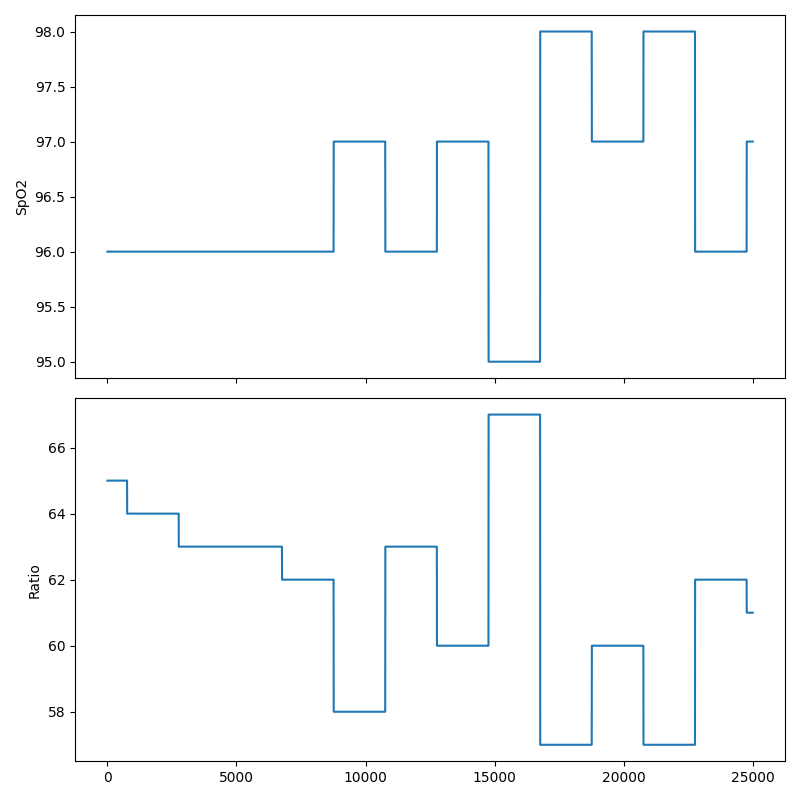

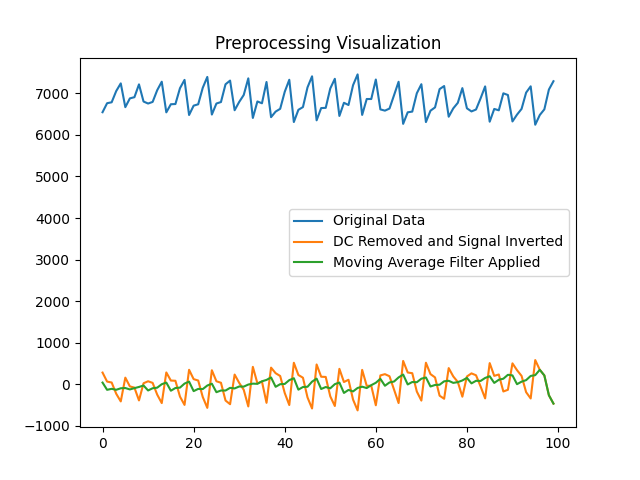

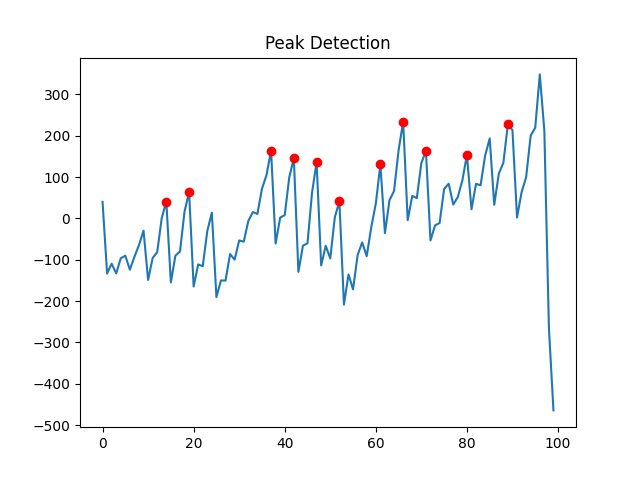

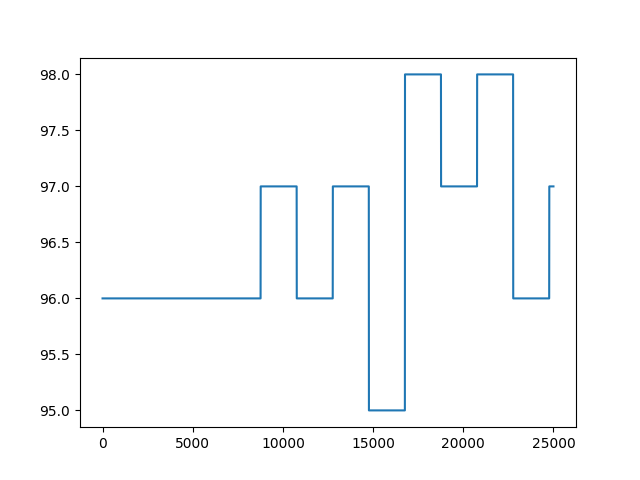

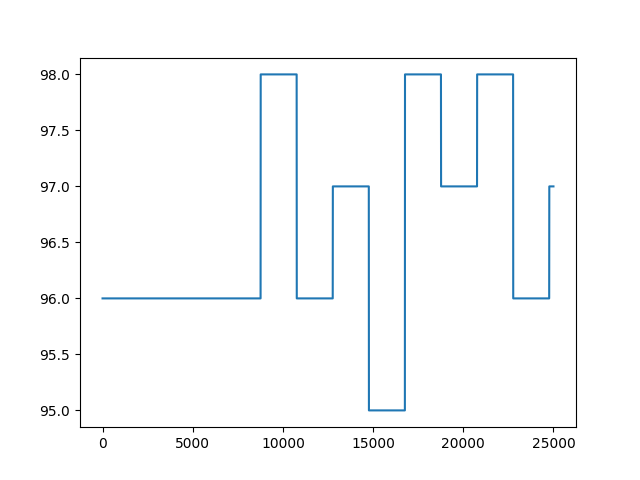

In [8]:
rd_buff = np.zeros(100)
ir_buff = np.zeros(100)
idx = 0
dec = 0
buff_num = 0
pr = 0
spo = 0
rat = 0

for i in range(len(ir)):
    if (i < 2100):
        pr = hr[i]
        spo = sp[i]
        rat = rt[i]

        if first_calc_possible:
            if (dec == 20):
                rd_buff[idx] = int(rd[i]) >> 4
                ir_buff[idx] = int(ir[i]) >> 4
                idx += 1
                dec = 0
        else:
            if (i == first_calc_idx):
                dec = 0
                idx = 0
            
            if (dec == 20):
                rd_buff[idx] = int(rd[i]) >> 4
                ir_buff[idx] = int(ir[i]) >> 4
                idx += 1
                dec = 0
    
    else:
        if (i == first_calc_idx):
            pr, spo, rat = find_spo2(ir_buff, rd_buff, True)
            idx = 0
        else:
            if (dec == 20):
                rd_buff[idx] = int(rd[i]) >> 4
                ir_buff[idx] = int(ir[i]) >> 4
                idx += 1
                dec = 0
            
            if (idx == 100):
                pr, spo, rat = find_spo2(ir_buff, rd_buff, buff_num == 1)
                idx = 0
                buff_num += 1
    
    heart_rate.append(pr)
    spo2.append(spo)
    ratios.append(rat)

    dec += 1

plt.figure()
plt.plot(spo2)

plt.figure()
plt.plot(sp)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# Plot SpO2
ax1.plot(spo2)
ax1.set_ylabel("SpO2")

ax2.plot(ratios)
ax2.set_ylabel("Ratio")

fig.set_label("Ratio and SpO2 Over Time")

plt.tight_layout()
plt.show()